In [ ]:
# ============================================
# STEP 1: INSTALL LIBRARIES
# ============================================

!pip install -q ultralytics roboflow opencv-python pyyaml

In [ ]:
!pip install -q roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="QiLHd1UFUSbCTJE6npvn")

project = rf.workspace("puspak").project("fruit-ripeness-detection-zzkqi")
version = project.version(2)

dataset = version.download("yolov8")

print("Dataset downloaded successfully!")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fruit-Ripeness-Detection--2 in yolov8:: 100%|██████████| 19198/19198 [00:01<00:00, 10911.17it/s]

Dataset downloaded successfully!
Dataset location: /content/Fruit-Ripeness-Detection--2


In [ ]:
# ============================================
# STEP 1: SET DATASET PATH
# ============================================

import os

DATASET_PATH = dataset.location

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset path: /content/Fruit-Ripeness-Detection--2
Dataset exists: True


In [ ]:
# ============================================
# STEP 2: CHECK DATASET STRUCTURE
# ============================================

for split in ["train", "valid", "test"]:

    split_path = os.path.join(DATASET_PATH, split)

    print(f"\n{split.upper()}")
    print("Folder exists:", os.path.exists(split_path))

    if os.path.exists(split_path):
        print("Contents:", os.listdir(split_path))


TRAIN
Folder exists: True
Contents: ['labels', 'images']

VALID
Folder exists: True
Contents: ['labels', 'images']

TEST
Folder exists: True
Contents: ['labels', 'images']


In [ ]:
# ============================================
# STEP 3: COUNT IMAGES AND LABELS
# ============================================

for split in ["train", "valid", "test"]:

    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    image_count = len(os.listdir(image_dir))
    label_count = len(os.listdir(label_dir))

    print(f"\n{split.upper()}")
    print("Images:", image_count)
    print("Labels:", label_count)



TRAIN
Images: 6710
Labels: 6710

VALID
Images: 1922
Labels: 1922

TEST
Images: 961
Labels: 961


In [ ]:
# ============================================
# STEP 4: CHECK DATA.YAML
# ============================================

import yaml

yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Classes:", data["names"])
print("Number of classes:", data["nc"])
print("Train:", data["train"])
print("Validation:", data["val"])
print("Test:", data.get("test"))

Classes: ['overripe', 'ripe', 'rotten', 'unripe']
Number of classes: 4
Train: ../train/images
Validation: ../valid/images
Test: ../test/images


In [ ]:
# ============================================
# STEP 5: CHECK GPU
# ============================================

import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available.")

GPU available: True
GPU: Tesla T4


In [ ]:
# ============================================
# STEP 6: LOAD YOLO
# ============================================

!pip install -q ultralytics

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO model loaded successfully!


In [ ]:
# ============================================
# STEP 7: TRAIN YOLO MODEL
# ============================================

results = model.train(
    data=os.path.join(DATASET_PATH, "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    name="fruit_ripeness"
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fruit-Ripeness-Detection--2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_ripeness, nbs=64, nms=No

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Fruit_Ripeness_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project folder created:")
print(PROJECT_DIR)

Project folder created:
/content/drive/MyDrive/Fruit_Ripeness_Project


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Fruit_Ripeness_Project"

print("Project folder exists:", os.path.exists(PROJECT_DIR))

if os.path.exists(PROJECT_DIR):
    print("Files:")
    print(os.listdir(PROJECT_DIR))

Project folder exists: False


In [ ]:
import os

DRIVE_PATH = "/content/drive/MyDrive"

print("MyDrive exists:", os.path.exists(DRIVE_PATH))

if os.path.exists(DRIVE_PATH):
    print("\nFiles/folders in MyDrive:")
    print(os.listdir(DRIVE_PATH))

MyDrive exists: True

Files/folders in MyDrive:
['Screenshot_20250310_115932_Messages.jpg', 'dony montage.mp4', 'DOC-20250802-WA0003..pdf', 'DOC-20250812-WA0000..pdf', 'Eclipse Lab qns.txt', 'IMG-20251111-WA0014.jpg', 'Donybinu.jpg', 'GT TRAINING', 'explain the whole program line by line with good....gsheet', 'FSD_Project', 'orange_dataset.ows', 'GT Training ADV ML', 'Colab Notebooks', 'archive', 'MERN_Book_Management_System.docx', 'DIM', 'Dony_15_AndriodLayouts.pdf', 'GT_Sep-Oct']


In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "best.pt" in files:
        matches.append(os.path.join(root, "best.pt"))

print("Found best.pt files:")

for path in matches:
    print(path)

Found best.pt files:


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving best.pt to best.pt


In [ ]:
import os

BEST_MODEL = "/content/best.pt"

print("Model exists:", os.path.exists(BEST_MODEL))
print("Model size:", round(os.path.getsize(BEST_MODEL) / (1024 * 1024), 2), "MB")

Model exists: True
Model size: 5.22 MB


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Fruit Ripeness Detection.zip to Fruit Ripeness Detection.zip


In [ ]:
import zipfile
import os

ZIP_FILE = "/content/Fruit Ripeness Detection.zip"

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir("/content"))

['.config', 'README.roboflow.txt', 'test', 'valid', 'README.dataset.txt', 'data.yaml', 'Fruit Ripeness Detection.zip', 'train', 'sample_data']


In [ ]:
import os

DATASET_PATH = "/content"

print("Dataset path:", DATASET_PATH)
print("data.yaml exists:", os.path.exists("/content/data.yaml"))
print("train exists:", os.path.exists("/content/train"))
print("valid exists:", os.path.exists("/content/valid"))
print("test exists:", os.path.exists("/content/test"))

Dataset path: /content
data.yaml exists: True
train exists: True
valid exists: True
test exists: True


In [ ]:
import yaml

with open("/content/data.yaml", "r") as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['overripe', 'ripe', 'rotten', 'unripe'], 'roboflow': {'workspace': 'puspak', 'project': 'fruit-ripeness-detection-zzkqi', 'version': 2, 'license': 'MIT', 'url': 'https://universe.roboflow.com/puspak/fruit-ripeness-detection-zzkqi/dataset/2'}}


In [ ]:
import yaml

corrected_data = {
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 4,
    "names": ["overripe", "ripe", "rotten", "unripe"]
}

with open("/content/data_corrected.yaml", "w") as f:
    yaml.dump(corrected_data, f, sort_keys=False)

print("Corrected data.yaml created!")

Corrected data.yaml created!


In [ ]:
import os

print("Train images:", os.path.exists("/content/train/images"))
print("Validation images:", os.path.exists("/content/valid/images"))
print("Test images:", os.path.exists("/content/test/images"))

Train images: True
Validation images: True
Test images: True


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 779.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 2.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving best.pt to best.pt


In [ ]:
import os

BEST_MODEL = "/content/best.pt"

print("best.pt exists:", os.path.exists(BEST_MODEL))

if os.path.exists(BEST_MODEL):
    print("Size:", round(os.path.getsize(BEST_MODEL) / (1024 * 1024), 2), "MB")

best.pt exists: True
Size: 5.22 MB


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

print("Trained model loaded successfully!")

Trained model loaded successfully!


In [ ]:
test_results = model.val(
    data="/content/data_corrected.yaml",
    split="test",
    imgsz=640
)


Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 170.4±65.6 MB/s, size: 7.2 KB)
val: Scanning /content/test/labels... 961 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 961/961 1.4Kit/s 0.7s
val: New cache created: /content/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 4.4s/it 4:29
                   all        961       1235      0.944      0.925      0.971      0.912
              overripe        131        173      0.923       0.83      0.929      0.852
                  ripe        310        371      0.976      0.981      0.993      0.944
                rotten        258        285      0.939      0.979      0.986      0.959
                unripe        275        406      0.937      0.911      0.975      0.895
Speed: 10.8m

In [ ]:
print("FINAL TEST PERFORMANCE")
print("=" * 45)
print(f"Images tested:       961")
print(f"Instances tested:    1235")
print(f"Precision:           {test_results.box.mp:.4f}")
print(f"Recall:              {test_results.box.mr:.4f}")
print(f"mAP50:               {test_results.box.map50:.4f}")
print(f"mAP50-95:            {test_results.box.map:.4f}")

FINAL TEST PERFORMANCE
Images tested:       961
Instances tested:    1235
Precision:           0.9439
Recall:              0.9253
mAP50:               0.9706
mAP50-95:            0.9123


In [ ]:
test_results.confusion_matrix.plot()

In [ ]:
import os

results_dir = "/content/runs/detect/val"

print(os.listdir(results_dir))

['val_batch2_pred.jpg', 'val_batch0_labels.jpg', 'confusion_matrix_normalized.png', 'val_batch2_labels.jpg', 'confusion_matrix.png', 'BoxR_curve.png', 'val_batch1_pred.jpg', 'BoxP_curve.png', 'BoxF1_curve.png', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'BoxPR_curve.png']


In [ ]:
import os

results_dir = "/content/runs/detect/val"

print("Results directory exists:", os.path.exists(results_dir))

if os.path.exists(results_dir):
    print("\nFiles saved:")
    for root, dirs, files in os.walk(results_dir):
        for file in files:
            print(os.path.join(root, file))

Results directory exists: True

Files saved:
/content/runs/detect/val/val_batch2_pred.jpg
/content/runs/detect/val/val_batch0_labels.jpg
/content/runs/detect/val/confusion_matrix_normalized.png
/content/runs/detect/val/val_batch2_labels.jpg
/content/runs/detect/val/confusion_matrix.png
/content/runs/detect/val/BoxR_curve.png
/content/runs/detect/val/val_batch1_pred.jpg
/content/runs/detect/val/BoxP_curve.png
/content/runs/detect/val/BoxF1_curve.png
/content/runs/detect/val/val_batch0_pred.jpg
/content/runs/detect/val/val_batch1_labels.jpg
/content/runs/detect/val/BoxPR_curve.png


Confusion matrix exists: True


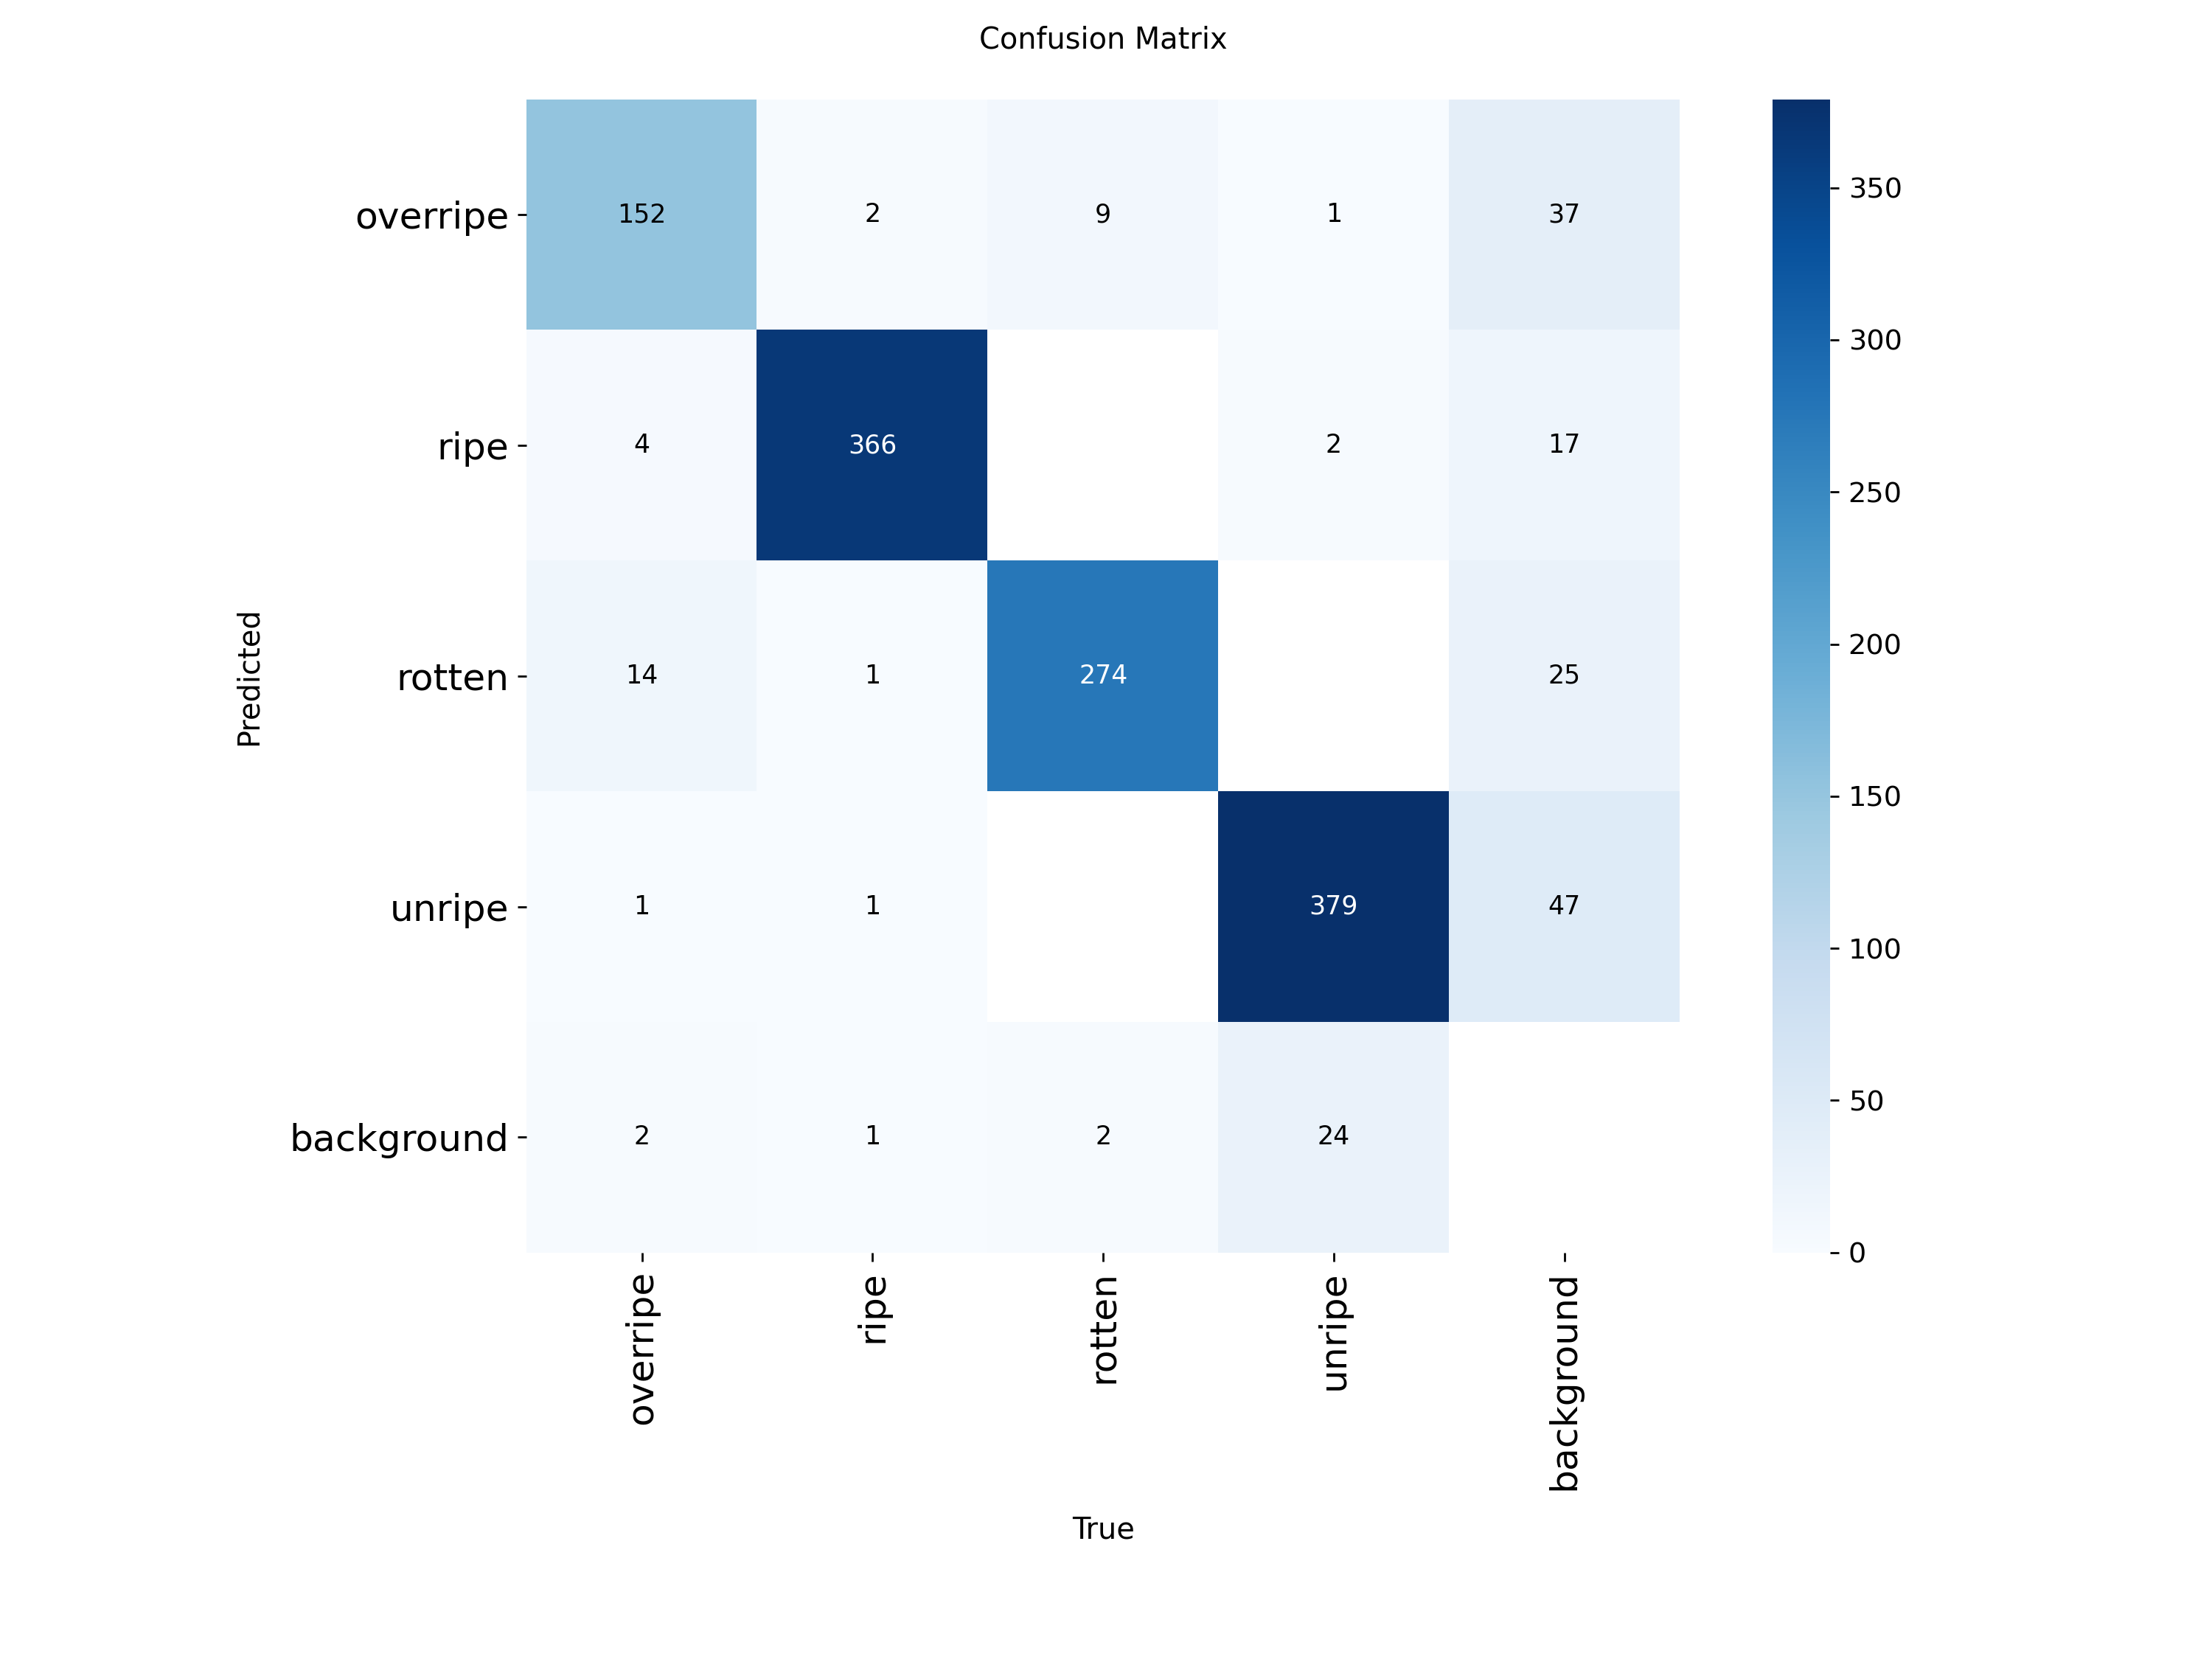

In [ ]:
from IPython.display import Image, display
import os

cm = "/content/runs/detect/val/confusion_matrix.png"

print("Confusion matrix exists:", os.path.exists(cm))

if os.path.exists(cm):
    display(Image(filename=cm))

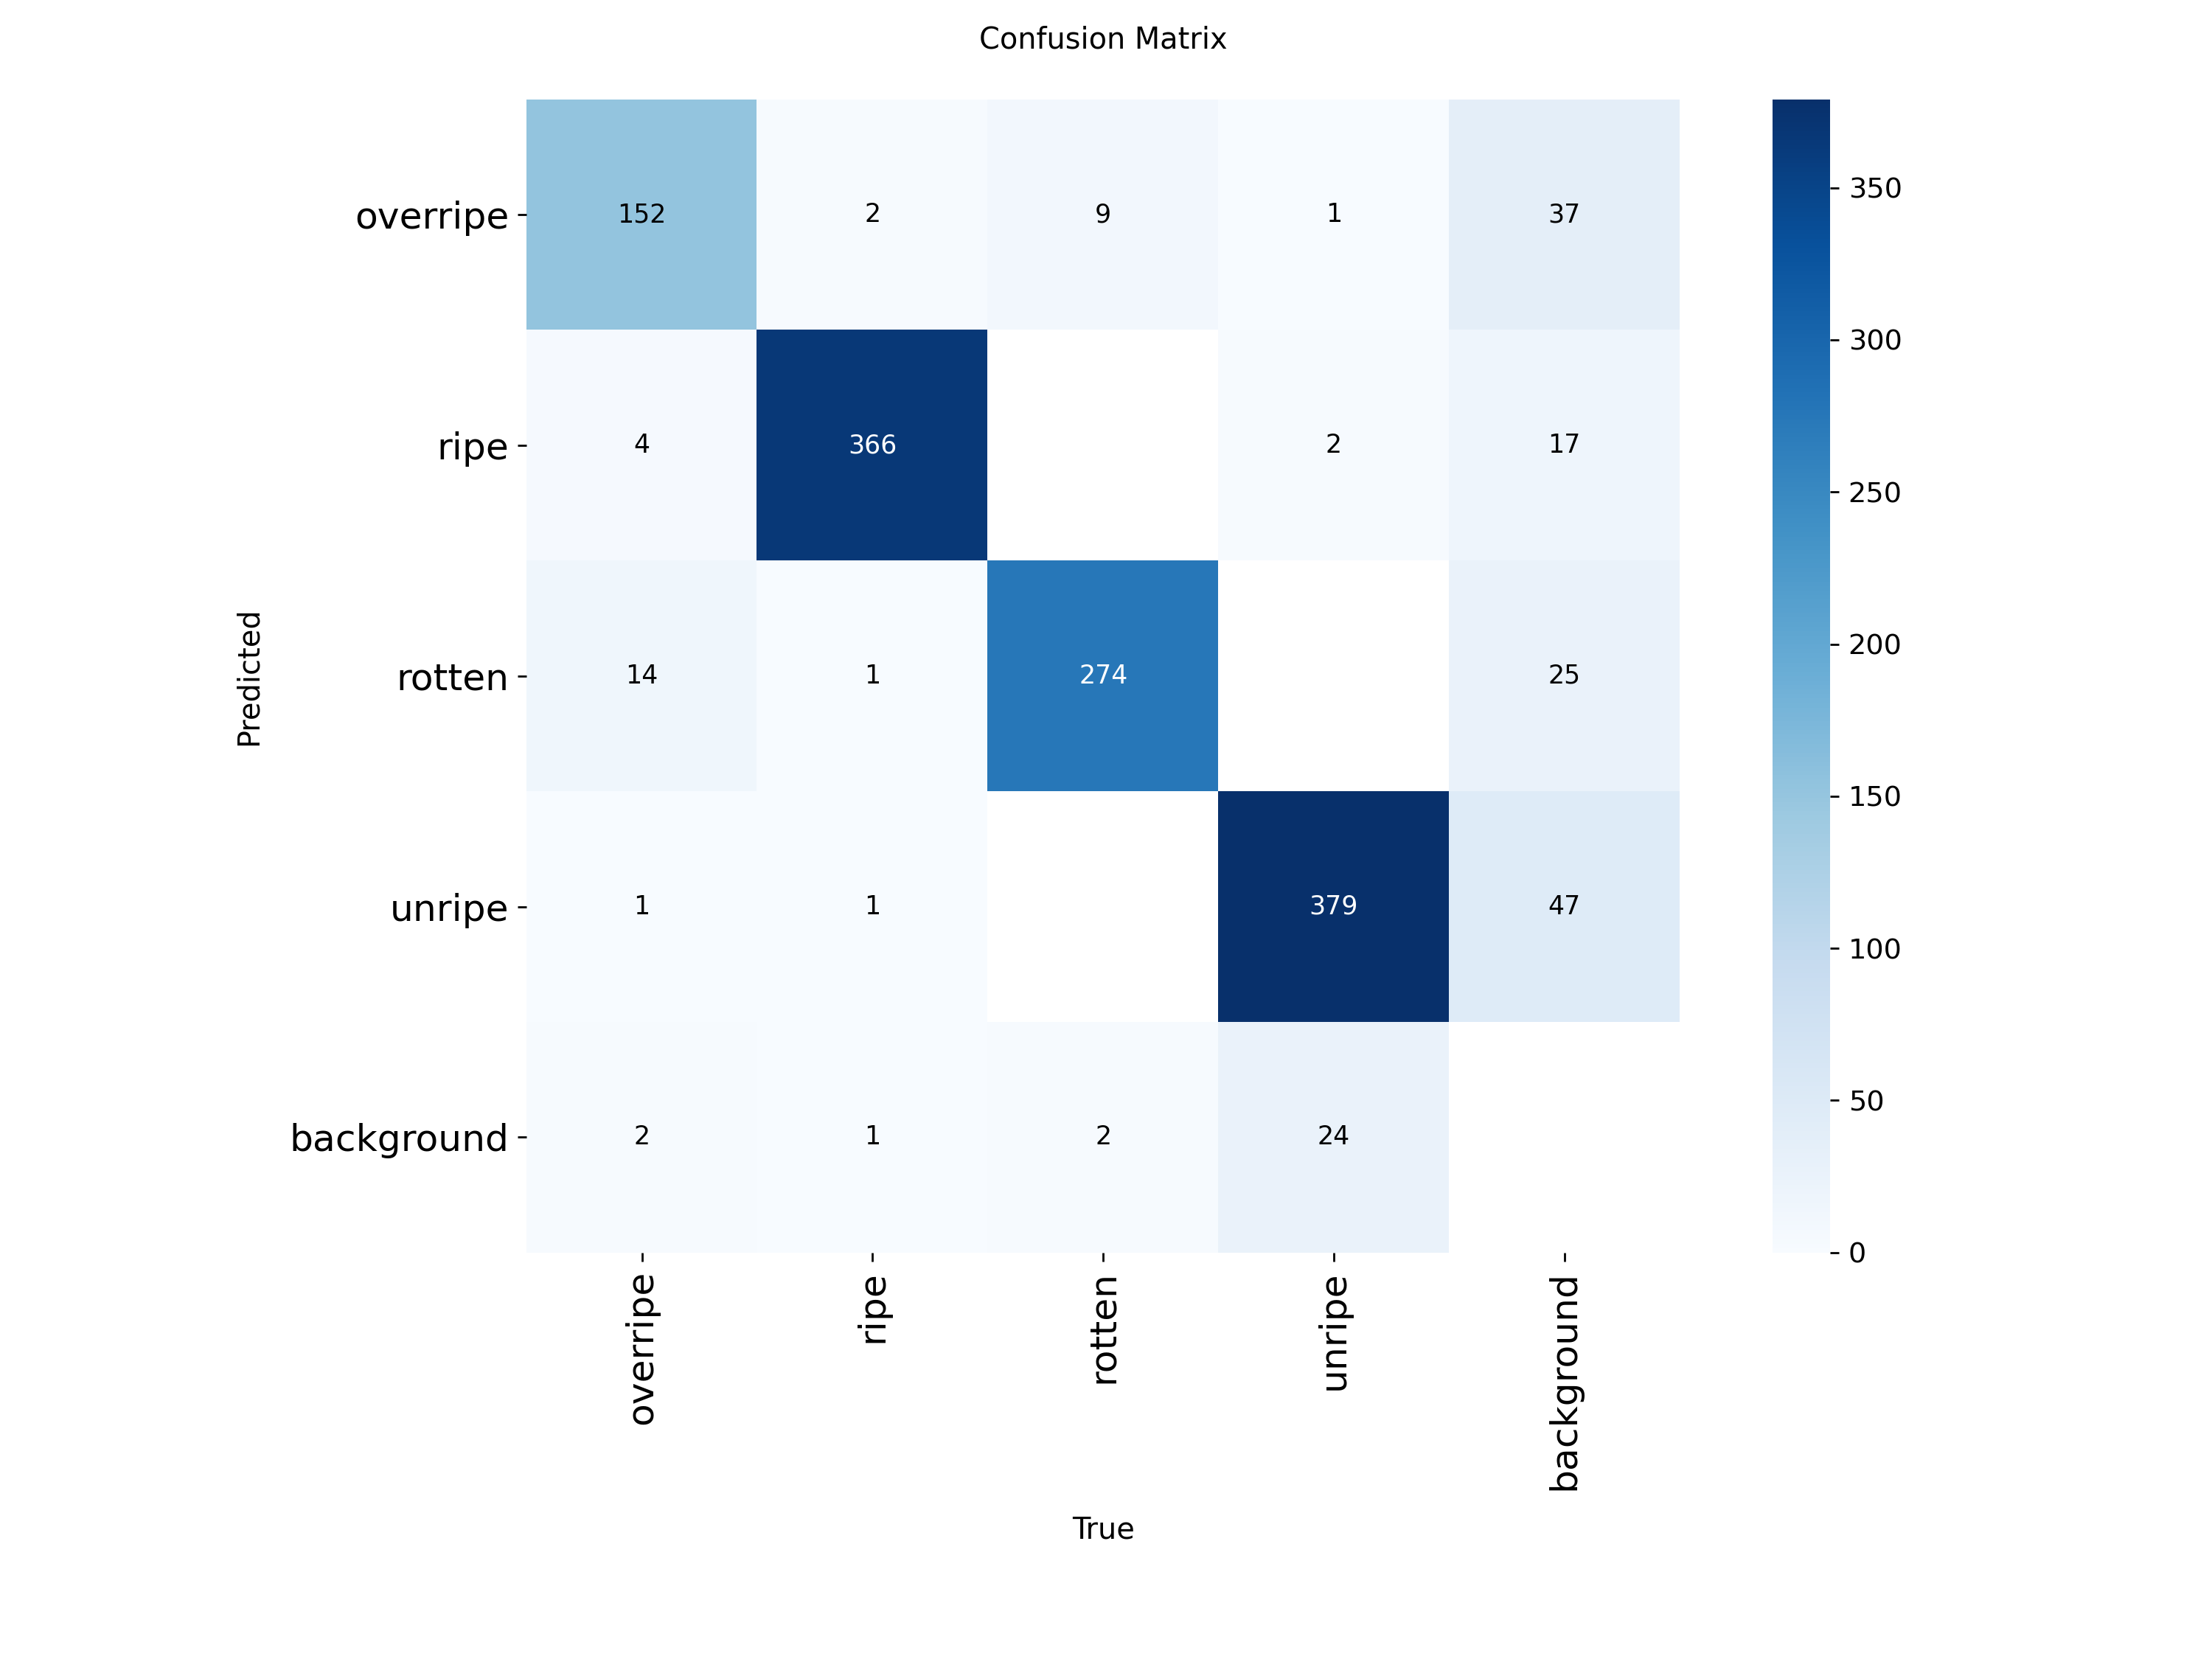

In [ ]:
from IPython.display import Image, display

display(Image(
    filename="/content/runs/detect/val/confusion_matrix.png"
))

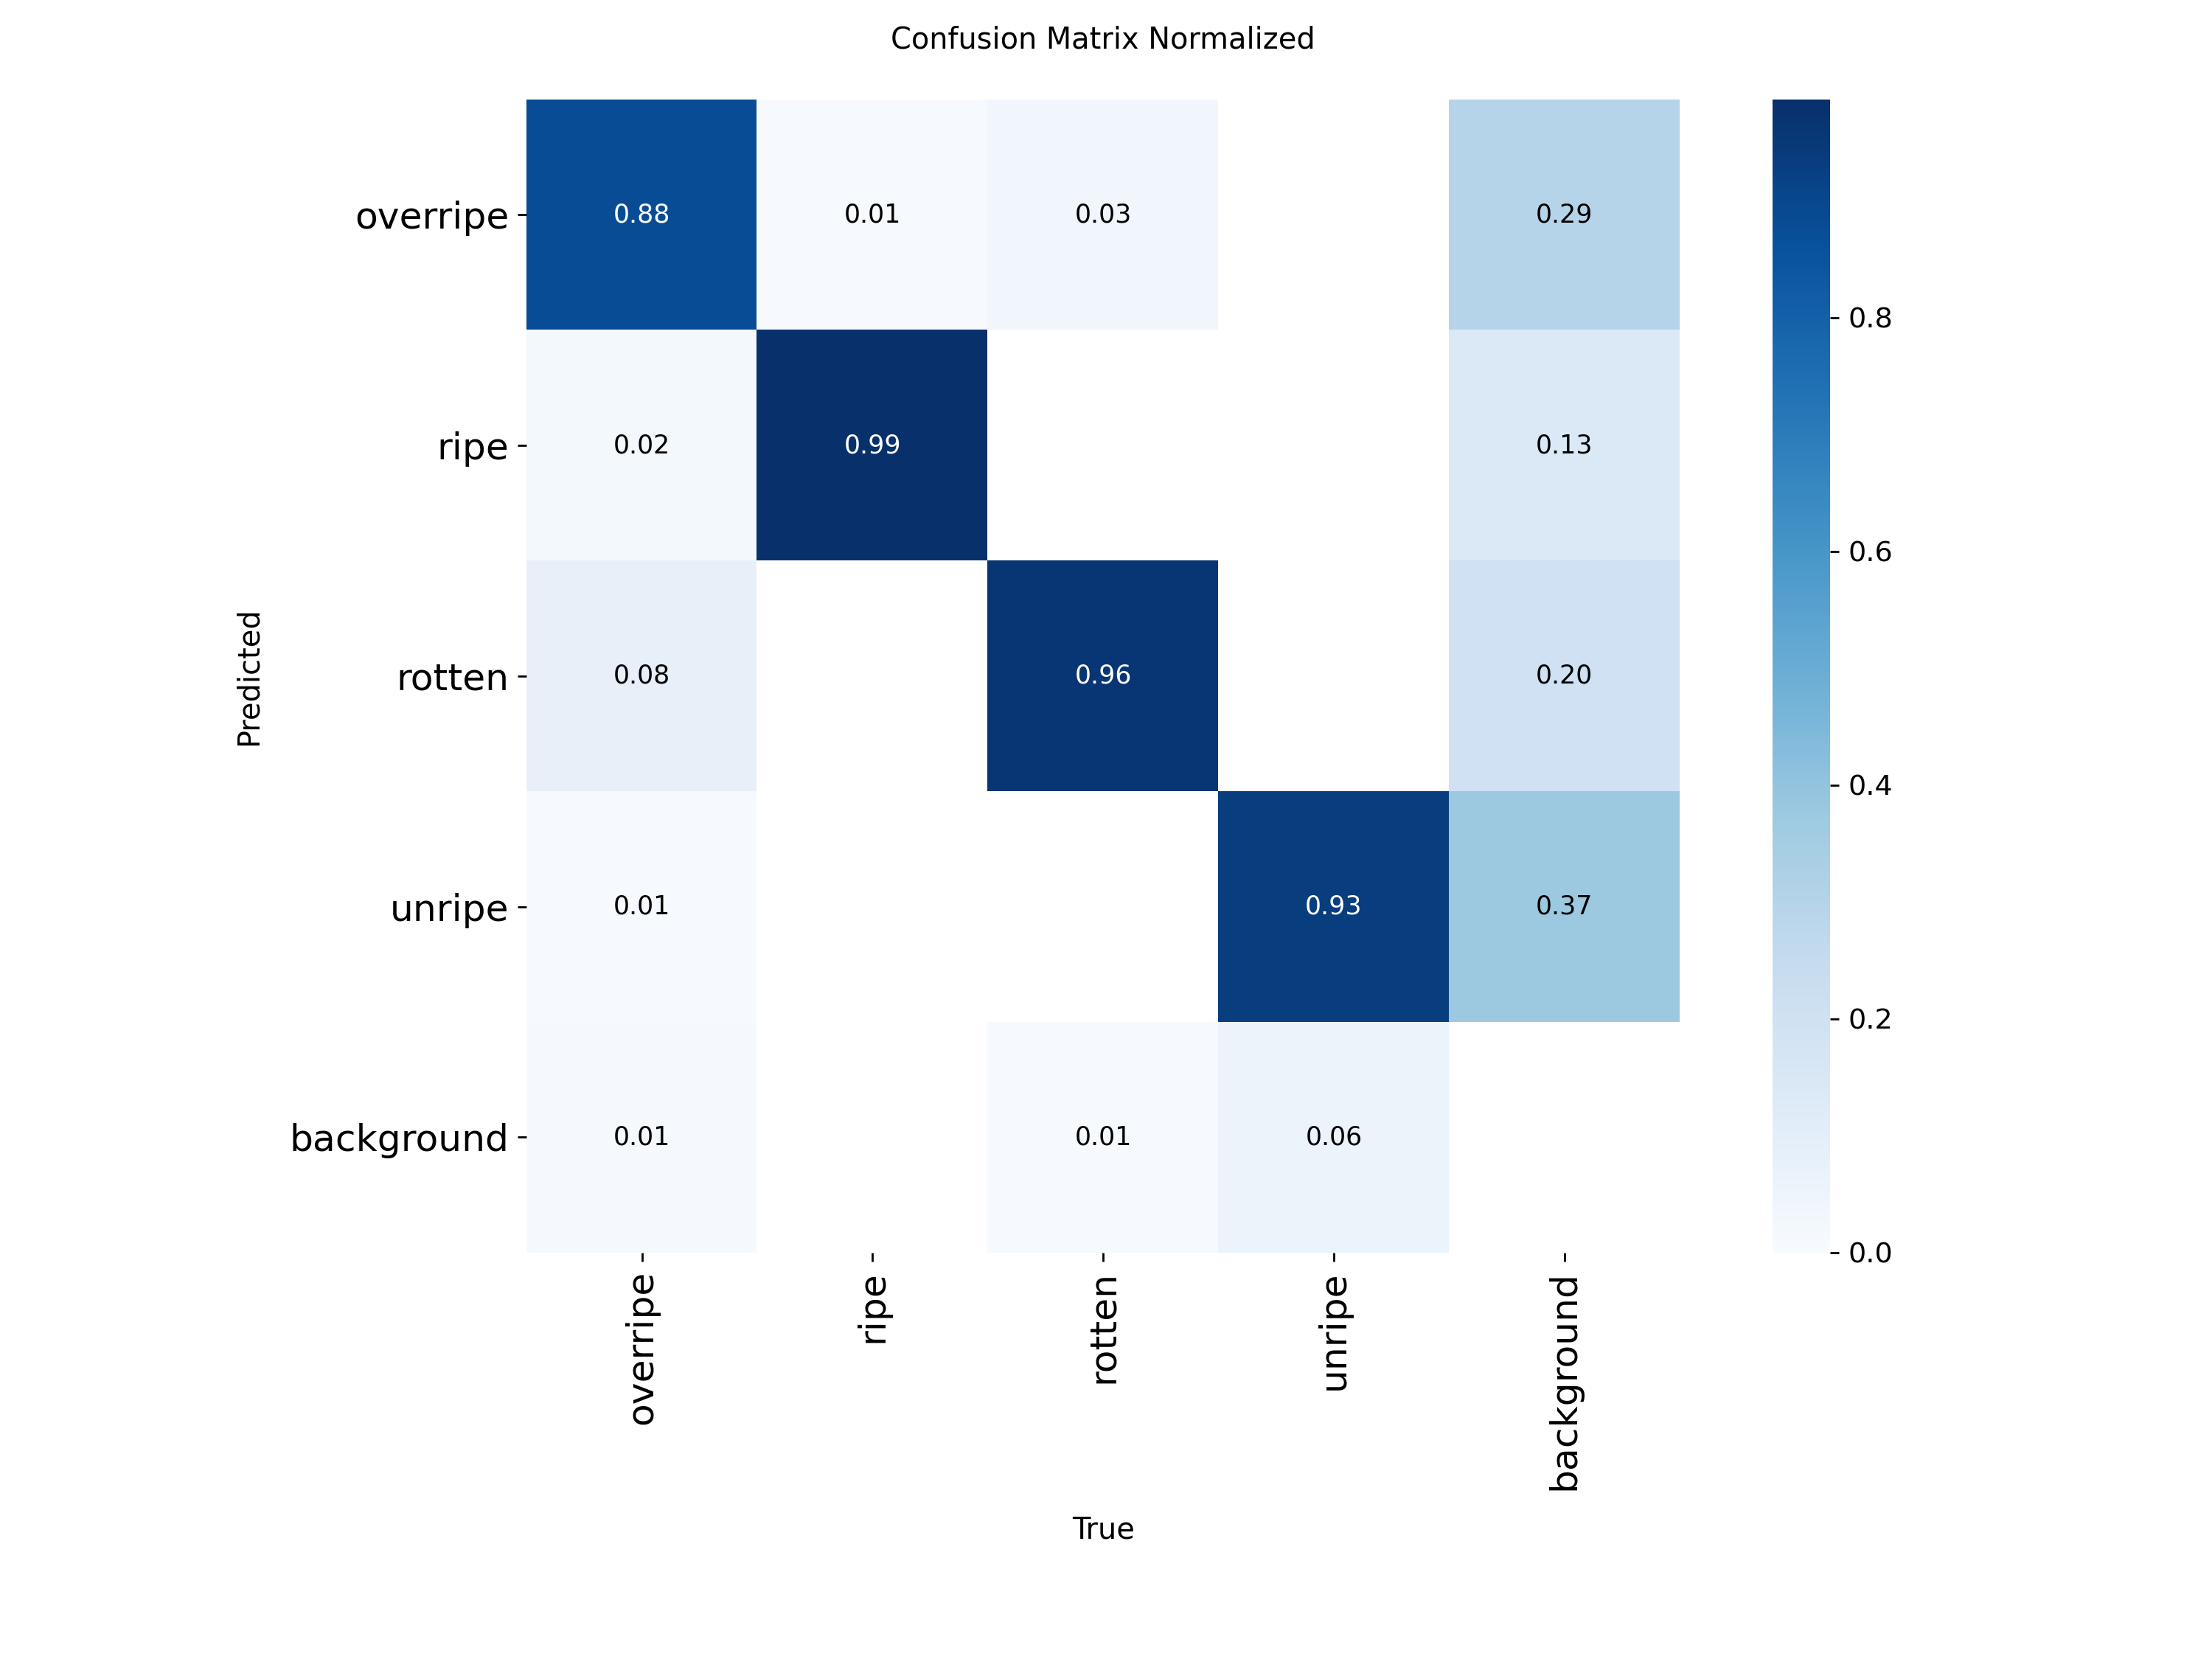

In [ ]:
display(Image(
    filename="/content/runs/detect/val/confusion_matrix_normalized.png"
))

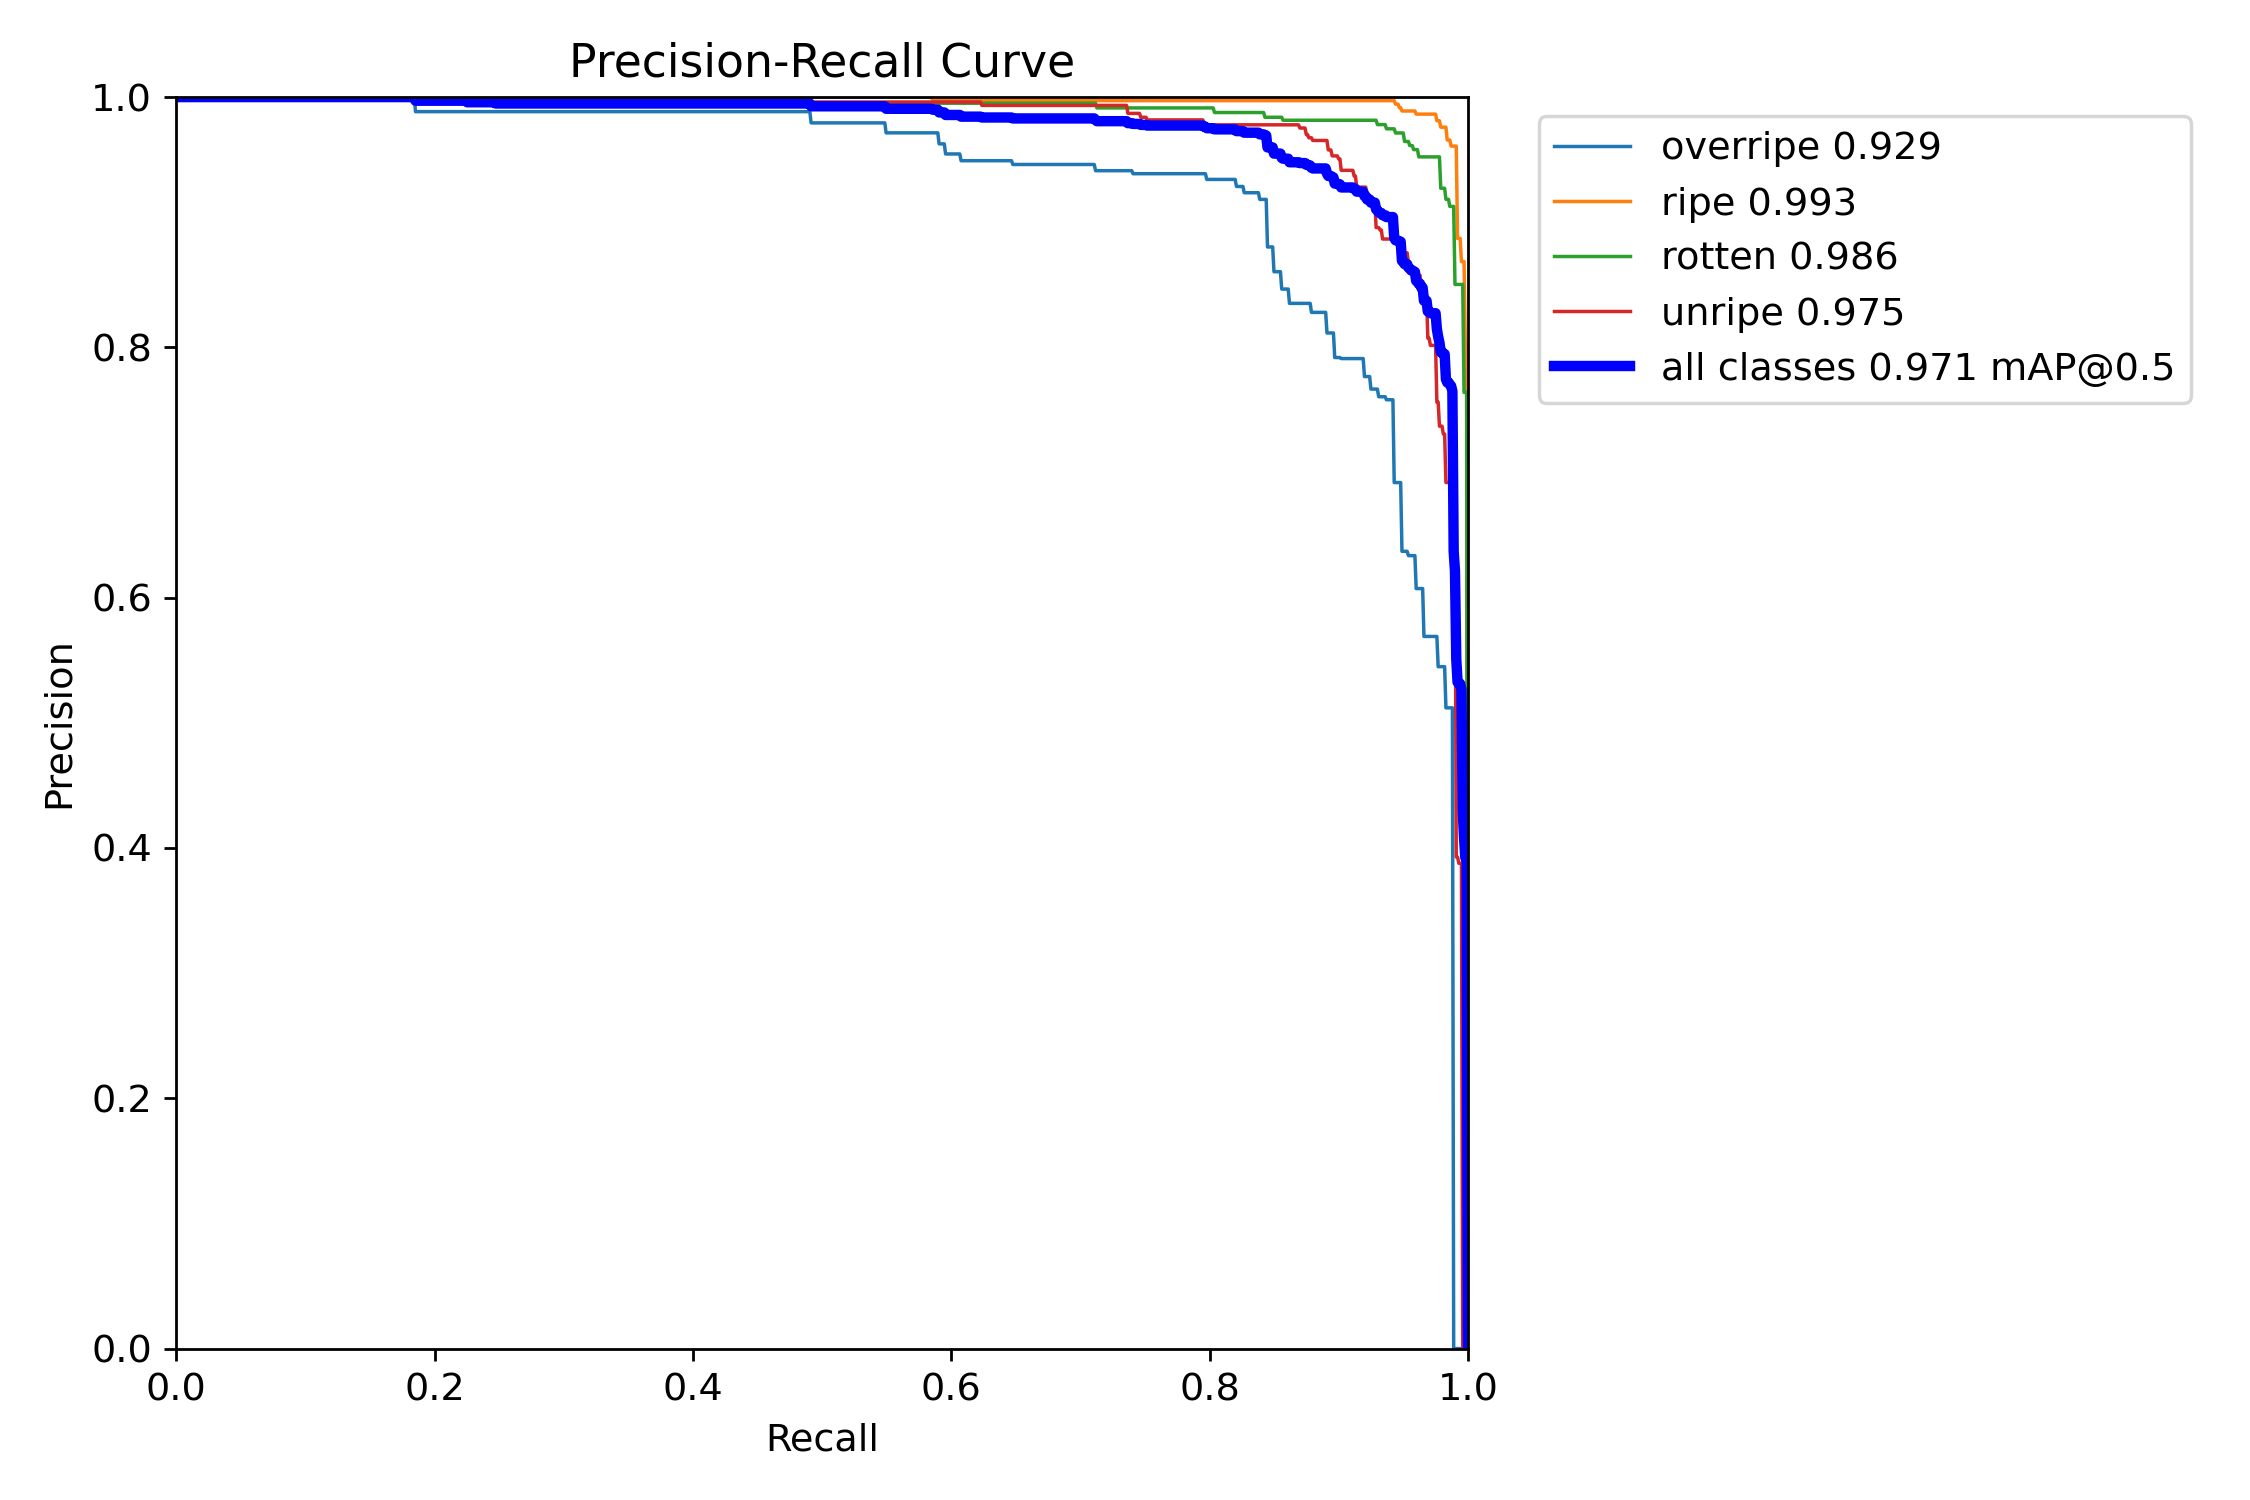

In [ ]:
display(Image(
    filename="/content/runs/detect/val/BoxPR_curve.png"
))

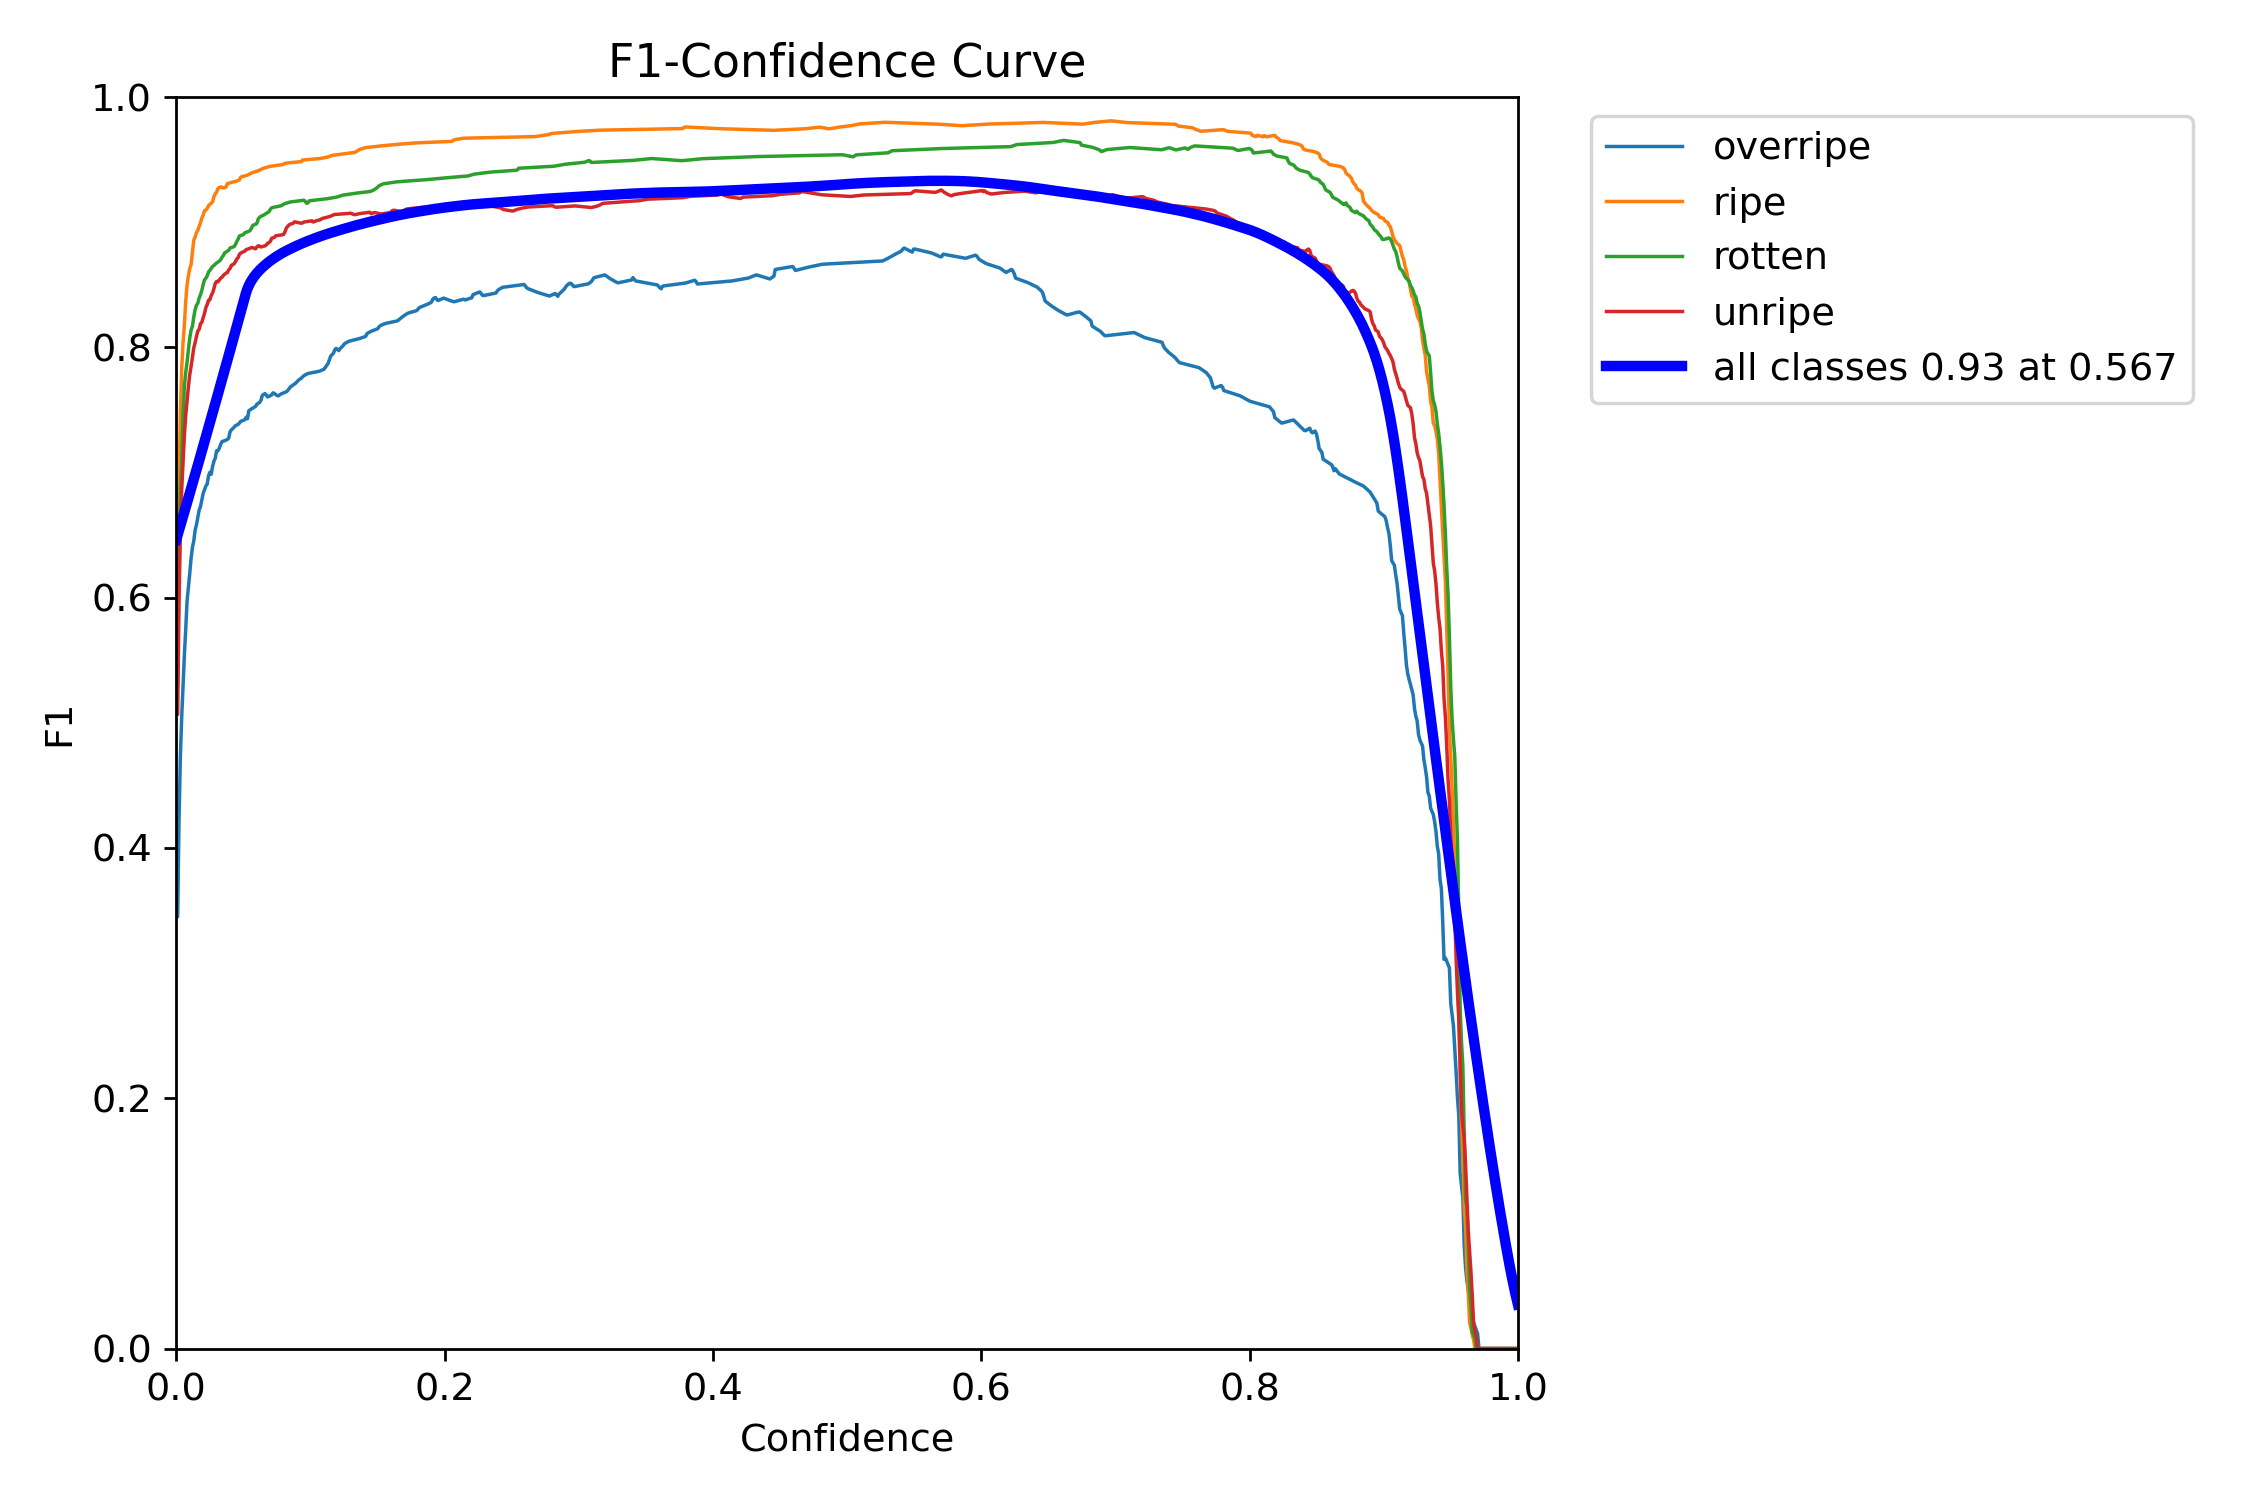

In [ ]:
display(Image(
    filename="/content/runs/detect/val/BoxF1_curve.png"
))

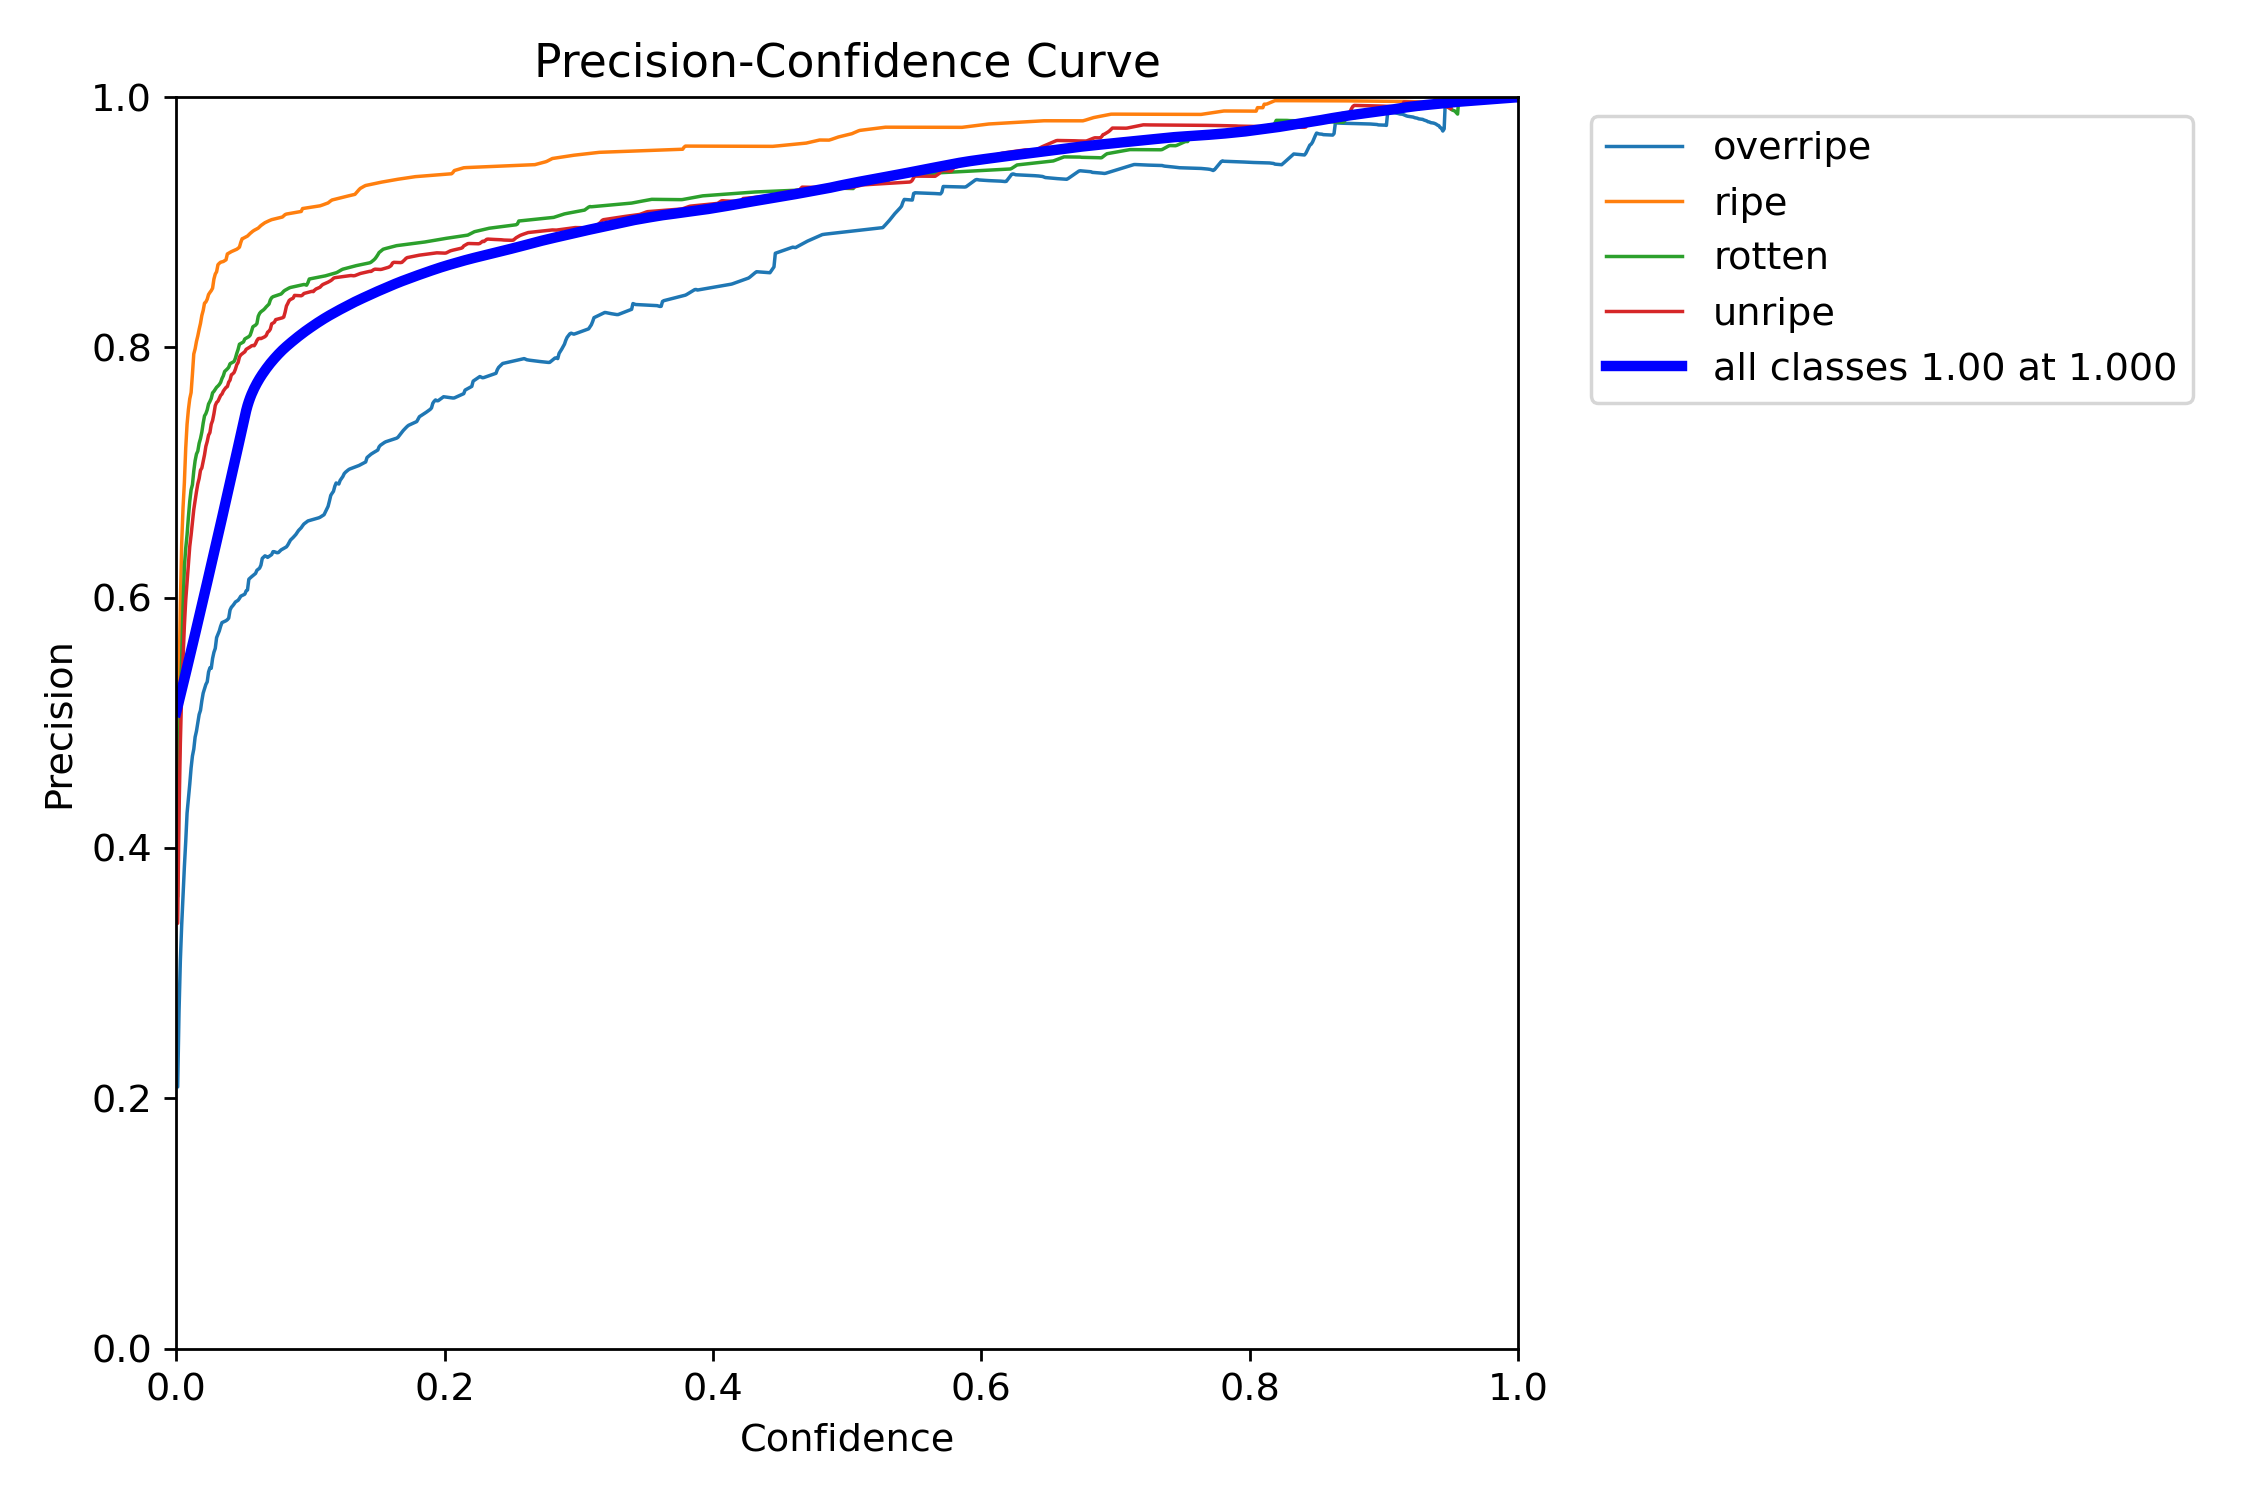

In [ ]:
display(Image(
    filename="/content/runs/detect/val/BoxP_curve.png"
))

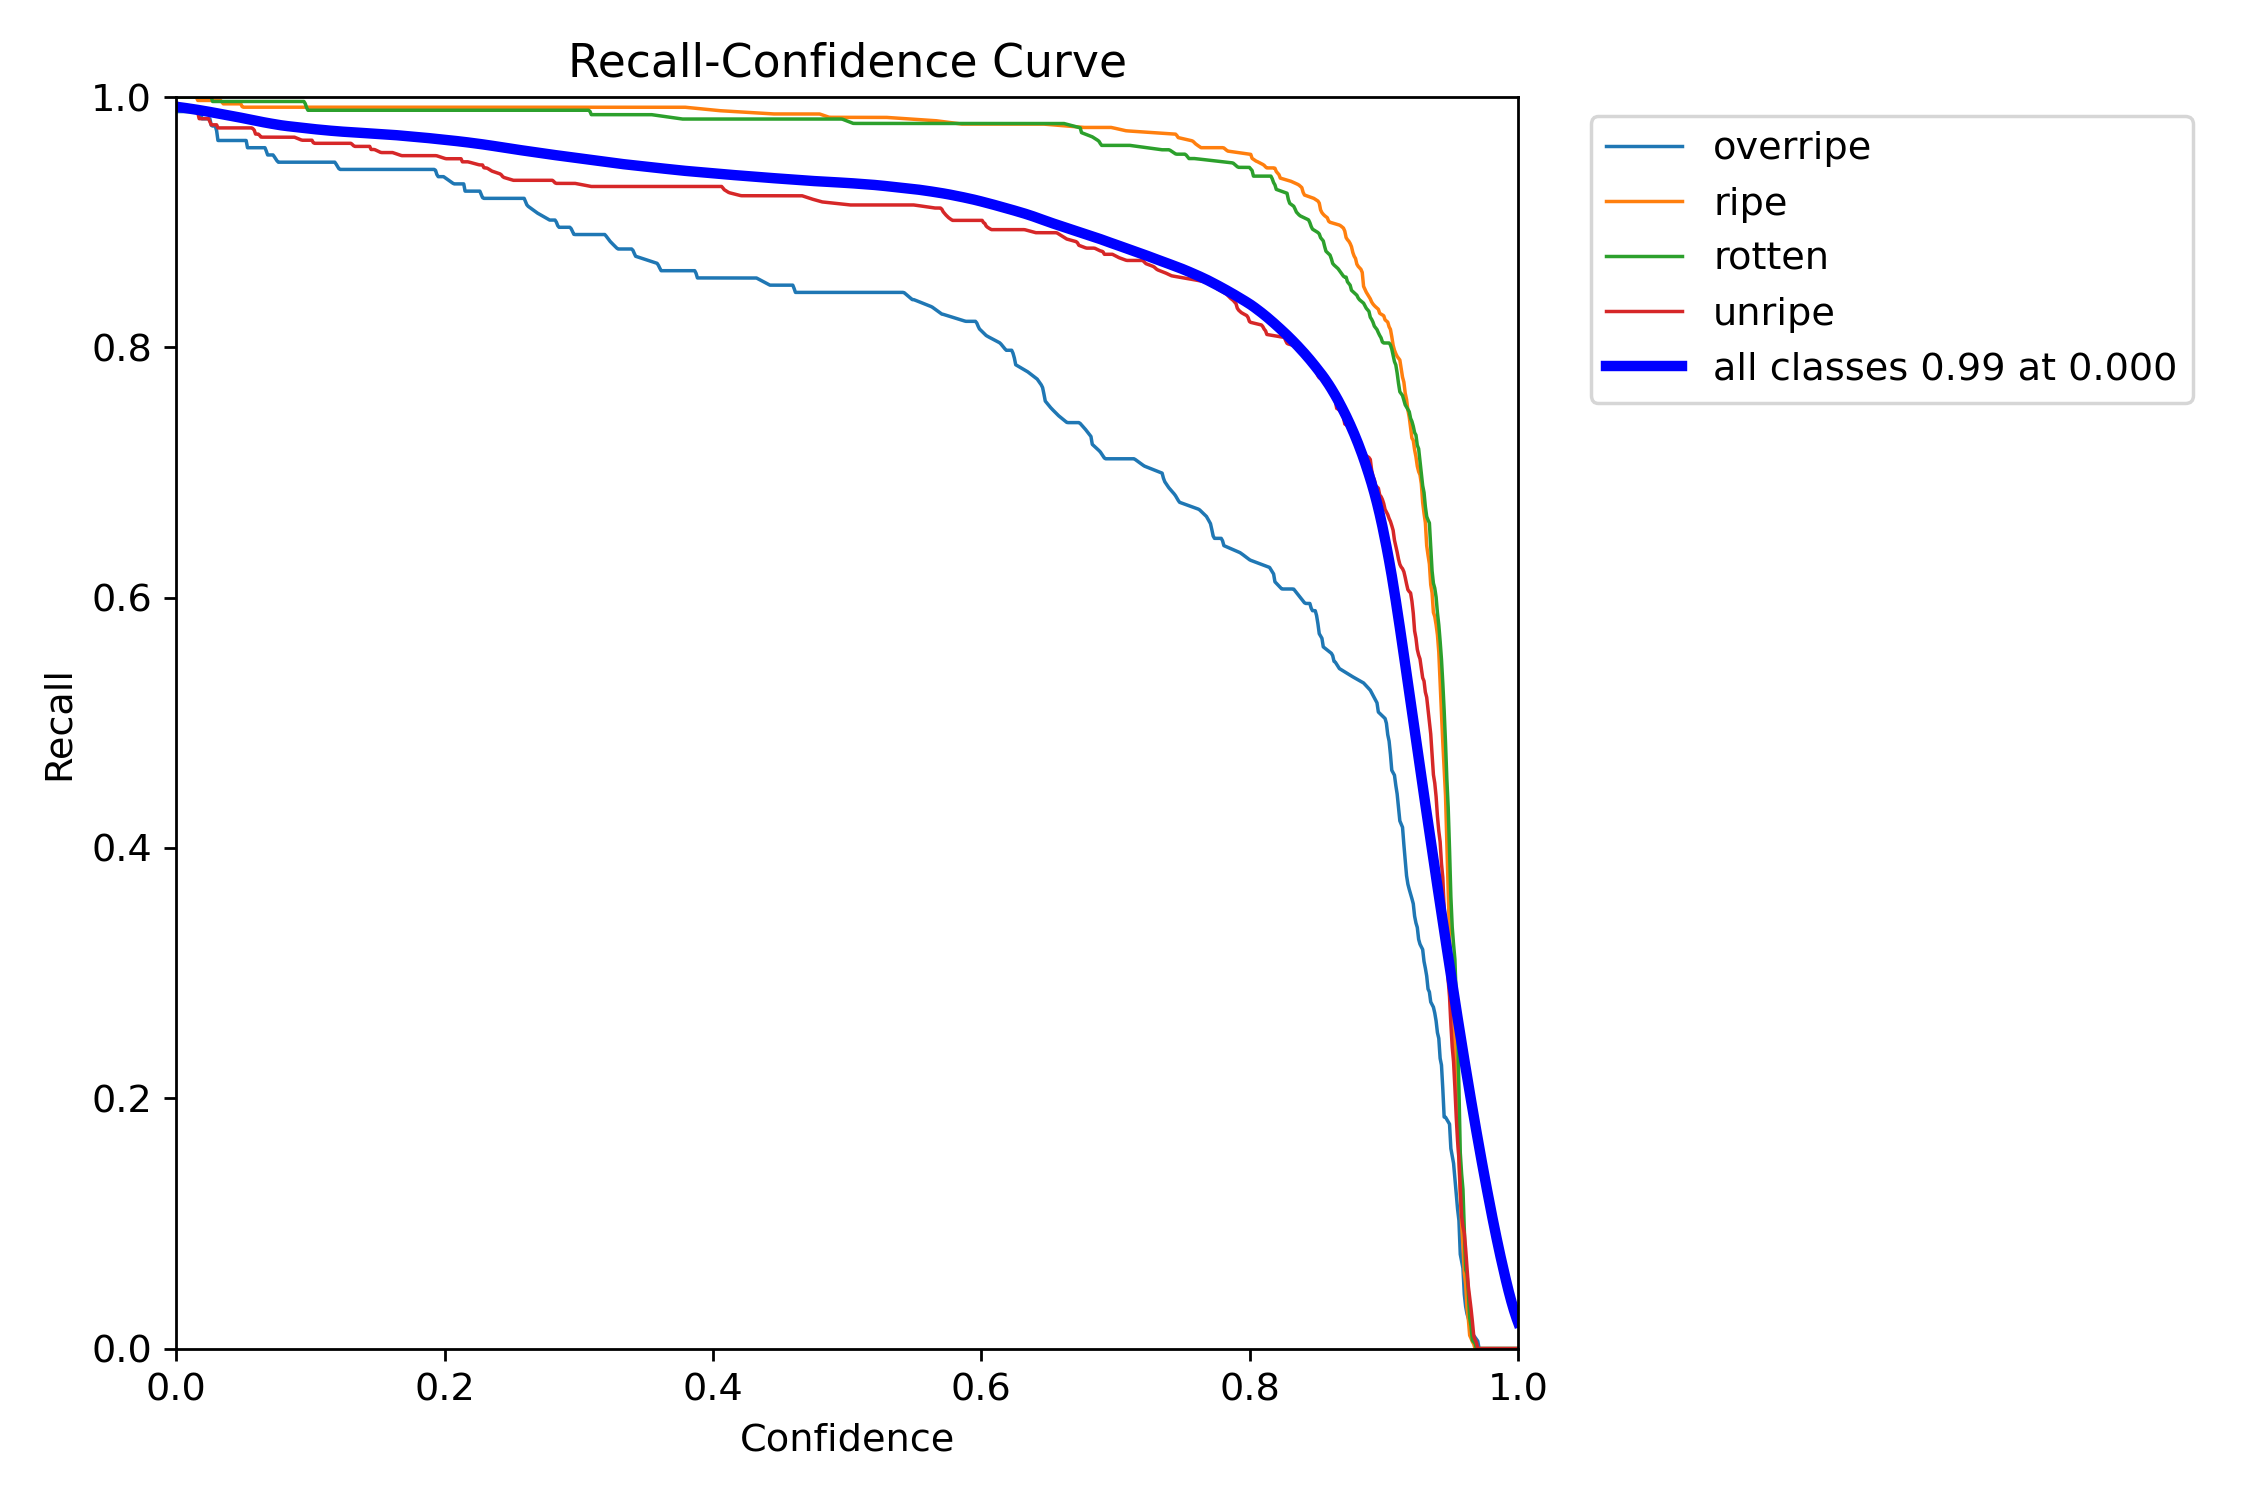

In [ ]:
display(Image(
    filename="/content/runs/detect/val/BoxR_curve.png"
))

In [ ]:
import os
import random

TEST_IMAGES = "/content/test/images"

images = [
    os.path.join(TEST_IMAGES, f)
    for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total test images:", len(images))

# Select 5 random test images
random_images = random.sample(images, 5)

for img in random_images:
    print(img)

Total test images: 961
/content/test/images/rotated_by_60_Screen-Shot-2018-06-12-at-8-52-16-PM_png_jpg.rf.d122bbb6556dcaba64127d9b630f9d39.jpg
/content/test/images/istockphoto-452367169-612x612_jpg.rf.e919e5875735cfd3c089373df1cb0b0e.jpg
/content/test/images/Raw_Banana5_0_8065_jpg.rf.8e9b1ff2baaa686f9e58d2c1f3c007c5.jpg
/content/test/images/istockphoto-1554542447-612x612_jpg.rf.9d1a918654b118676f62072bf3aa066b.jpg
/content/test/images/istockphoto-1601351924-612x612_jpg.rf.1d10ba206c0bb2894f6994e5be80529c.jpg


In [ ]:
results = model.predict(
    source=random_images,
    imgsz=640,
    conf=0.25,
    save=True
)

print("Predictions completed!")


0: 640x640 1 rotten, 350.0ms
1: 640x640 1 unripe, 350.0ms
2: 640x640 2 unripes, 350.0ms
3: 640x640 2 unripes, 350.0ms
4: 640x640 4 unripes, 350.0ms
Speed: 15.0ms preprocess, 350.0ms inference, 8.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Predictions completed!


Prediction files: 5


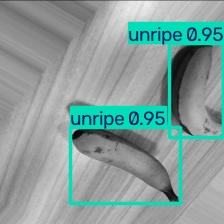

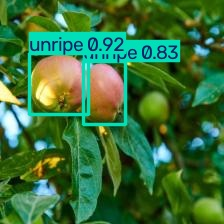

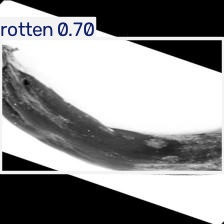

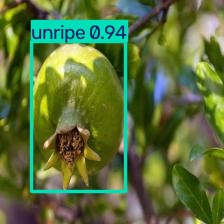

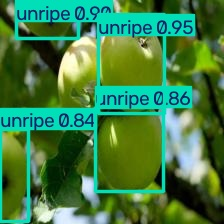

In [ ]:
from IPython.display import Image, display
import glob

prediction_files = glob.glob("/content/runs/detect/predict/*")

print("Prediction files:", len(prediction_files))

for file in prediction_files:
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        display(Image(filename=file))

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving applesnew.jpeg to applesnew.jpeg


In [ ]:
import os

new_image = list(uploaded.keys())[0]

results = model.predict(
    source=new_image,
    imgsz=640,
    conf=0.25,
    save=True
)

print("Prediction completed!")


image 1/1 /content/applesnew.jpeg: 448x640 3 overripes, 1 unripe, 156.3ms
Speed: 6.2ms preprocess, 156.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
Prediction completed!


In [ ]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    print(f"{class_name}: {confidence:.2%}")

overripe: 95.71%
overripe: 94.26%
overripe: 73.46%
unripe: 67.34%


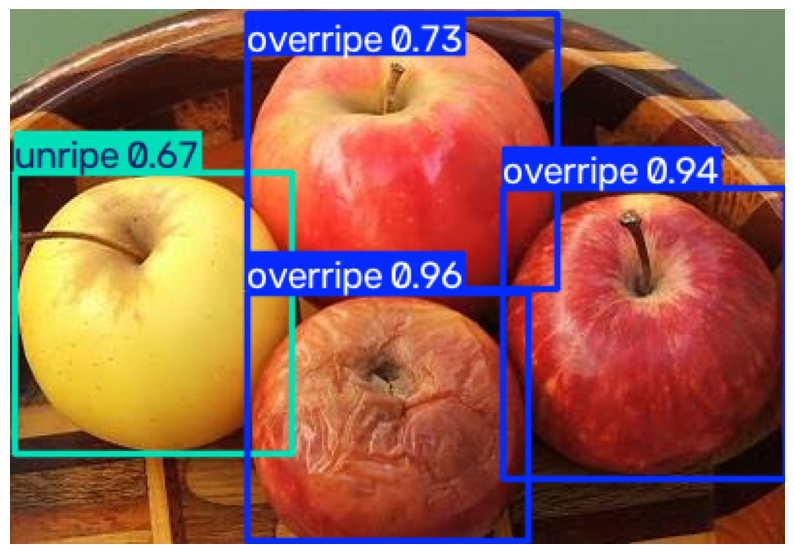

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Get the annotated image directly from YOLO's result
result_image = results[0].plot()

# Convert BGR to RGB
result_image = result_image[:, :, ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(result_image)
plt.axis("off")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving applelife.jpg to applelife.jpg


In [ ]:
import os

new_image = list(uploaded.keys())[0]

results = model.predict(
    source=new_image,
    imgsz=640,
    conf=0.25,
    save=True
)

print("Prediction completed!")


image 1/1 /content/applelife.jpg: 448x640 3 overripes, 1 ripe, 202.6ms
Speed: 21.1ms preprocess, 202.6ms inference, 2.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
Prediction completed!


In [ ]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    print(f"{class_name}: {confidence:.2%}")

overripe: 89.39%
overripe: 87.85%
ripe: 50.73%
overripe: 50.09%


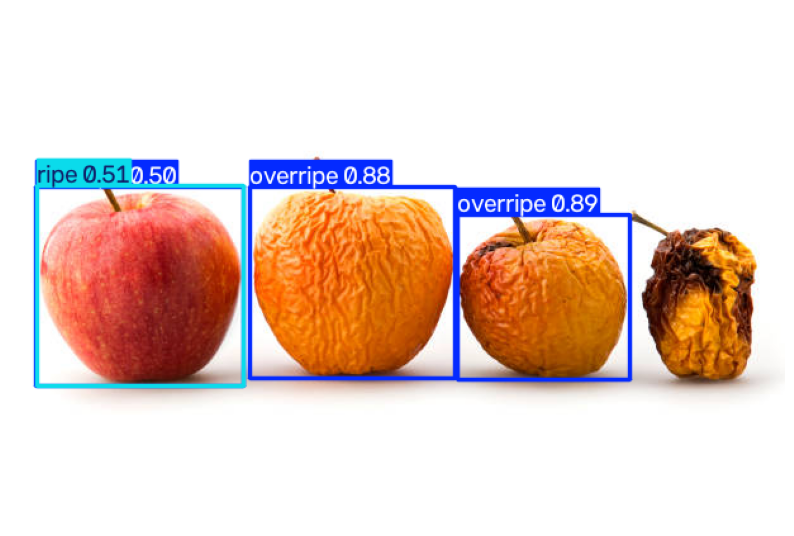

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Get the annotated image directly from YOLO's result
result_image = results[0].plot()

# Convert BGR to RGB
result_image = result_image[:, :, ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(result_image)
plt.axis("off")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving robusta.jpg to robusta.jpg


In [ ]:
import os

new_image = list(uploaded.keys())[0]

results = model.predict(
    source=new_image,
    imgsz=640,
    conf=0.25,
    save=True
)

print("Prediction completed!")


image 1/1 /content/robusta.jpg: 640x640 2 unripes, 304.7ms
Speed: 8.4ms preprocess, 304.7ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Prediction completed!


In [ ]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    print(f"{class_name}: {confidence:.2%}")

unripe: 50.99%
unripe: 45.68%


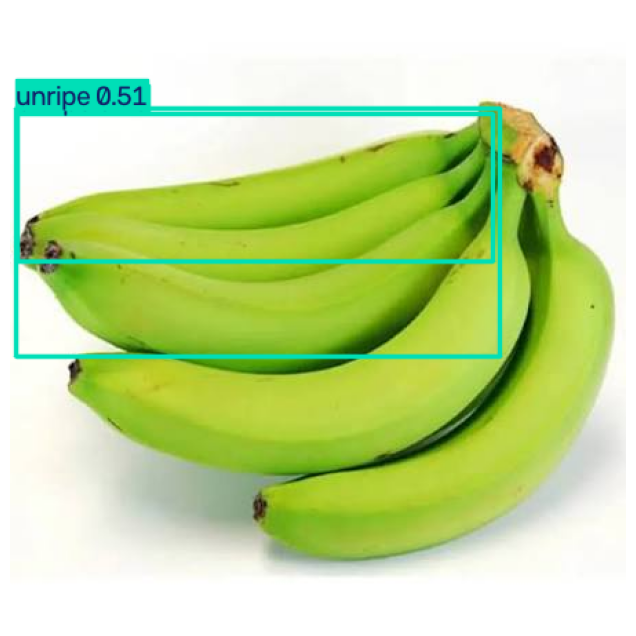

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

# Get the annotated image directly from YOLO's result
result_image = results[0].plot()

# Convert BGR to RGB
result_image = result_image[:, :, ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(result_image)
plt.axis("off")
plt.show()